In [2]:
#import tensorflow as tf
import os #for saving plots to specified directory

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt #for visualization
from sympy import im, symbols, Eq, solve, Matrix
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

In [4]:
print("hello")

hello


In [5]:
#set up compartmental model
S = symbols('S')
E = symbols('E')
I = symbols('I')
R  = symbols('R')
beta = symbols('beta')
gamma = symbols('gamma')
alpha = symbols('alpha')
Lambda = symbols('Lambda')
mu = symbols('mu')

#estimated strep parameters
#gamma = 1
#alpha = 1

dS = Lambda - beta*S*I - mu*S
dE = beta*S*I - alpha*E - mu*E
dI = alpha*E - gamma*I - mu*I
dR = gamma*I - mu*R

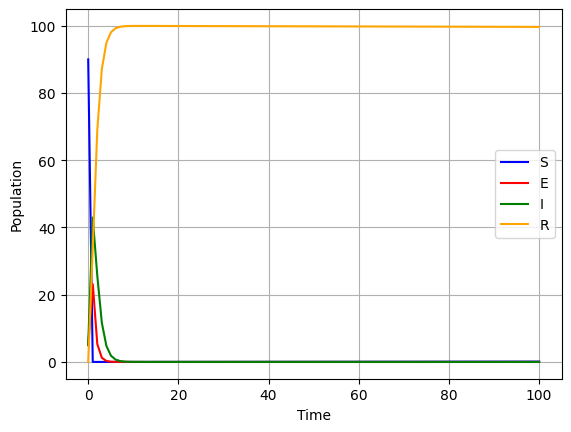

In [6]:
gamma = 1
#alpha = 0.29
alpha = 1.46
#alpha = 2.347510026817774 #transition time from low to high density; not infectivity!
beta = 3.374 #calculated from root-finding the imaginary values in the Jacobian
mu = 0.00003333333 #1/lifespan of person
Lambda = 0.001

#from literature: r0 = 2.2 giving beta=0.22


def model(t, state):
    S,E,I,R = state
    dSdt = Lambda - beta*S*I - mu*S
    dEdt = beta*S*I - alpha*E - mu*E
    dIdt = alpha*E - gamma*I - mu*I
    dRdt = gamma*I - mu*R
    return [dSdt,dEdt,dIdt,dRdt]

t_span = (0, 100)
initial = (90, 5, 5, 0)

t_evaluate = np.linspace(0, 100, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)


plt.plot(sol.t, sol.y[0], label='S', color='blue')
plt.plot(sol.t, sol.y[1], label='E', color='red')
plt.plot(sol.t, sol.y[2], label='I', color='green')
plt.plot(sol.t, sol.y[3], label='R', color='orange')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Proportion')

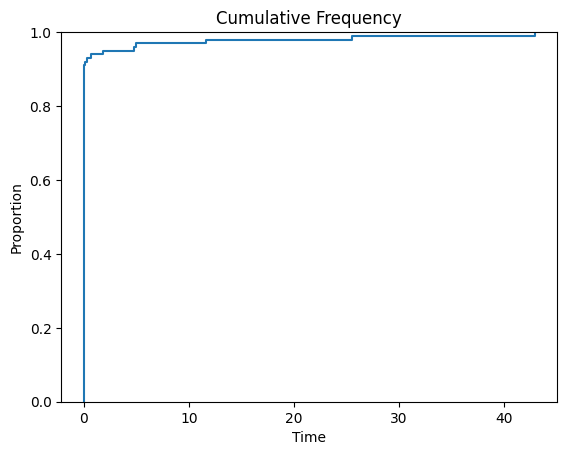

In [7]:
data = sol.y[2]
fig, ax = plt.subplots()

# Plot the exact cumulative curve
ax.ecdf(data, label="Cumulative Incidence")

ax.set_title("Cumulative Frequency")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion")

101.22001012200103


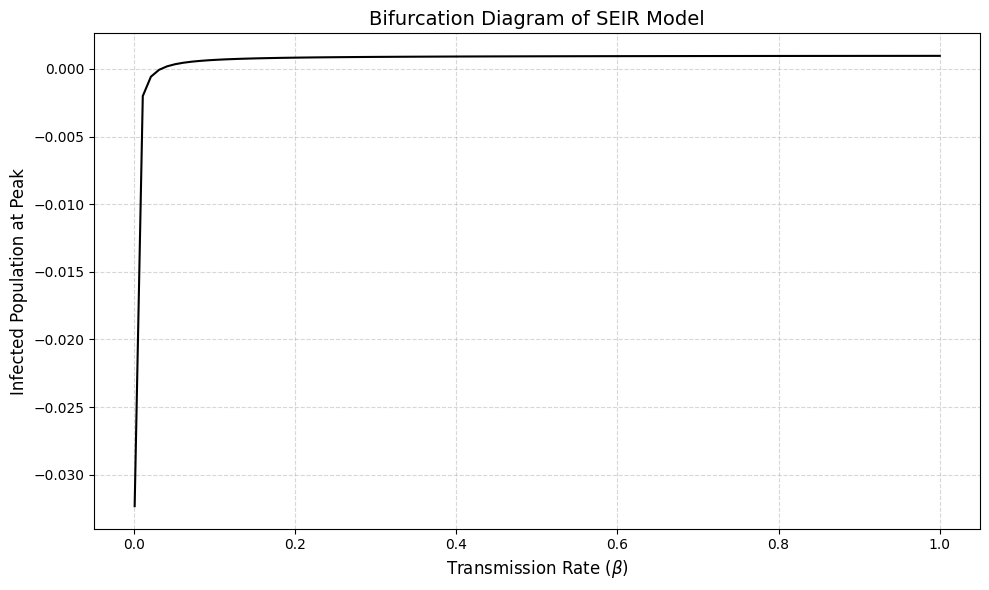

In [8]:
#bifurcation diagram for I* vs R0

#R0 = math.sqrt((alpha*beta*Lambda)/(mu*(mu+alpha)*(mu*gamma)))
#corrected from discussion with Brendan on R0 calculation 6/04
R0 = (Lambda/mu)*(beta/gamma) #here we assume a steady population where deaths and immigration over a three-week interval are negligible
#R0 = math.sqrt(Lambda/mu)*math.sqrt(beta/gamma) #here we assume a steady population where deaths and immigration over a three-week interval are negligible
print(R0)

beta_min = 0.001
beta_max = 1

beta_evaluate = np.linspace(beta_min, beta_max, 100)
transient_time = 14 #model peaks quickly

bifurcation_beta = []
bifurcation_I = []



for val in range(len(beta_evaluate)):
    beta = beta_evaluate[val]
    #print(val)
    #print(beta)
    #breakpoint()
    I_steady = ((Lambda*alpha)/((gamma+mu)*(alpha+mu)))-(mu/beta)
    bifurcation_I.append(I_steady)
    bifurcation_beta.append(beta)
#     sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)

#     I_pop = sol.y[2]

    
#     # Isolate the attractor (discard the transient burn-in period)
#     # We take the local peaks to build a clear bifurcation diagram
#     I_steady = I_pop[transient_time :]
    
#     peaks = []
#     for i in range(1, len(I_steady) - 1):
#         if I_steady[i] > I_steady[i-1] and I_steady[i] > I_steady[i+1]:
#             peaks.append(I_steady[i])
            
#     # Store points for plotting
#     for peak in peaks:
   
#         bifurcation_I.append(peak)


# print("finished iterations")
#print(len(bifurcation_beta))
#print(len(bifurcation_I))
#breakpoint()
plt.figure(figsize=(10, 6))
plt.plot(bifurcation_beta, bifurcation_I, color='black') #, alpha=0.5)

plt.title('Bifurcation Diagram of SEIR Model', fontsize=14)
plt.xlabel('Transmission Rate ($\\beta$)', fontsize=12)
plt.ylabel('Infected Population at Peak', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [9]:
#Look at the Jacobian eigenvalues to check for oscillatory imaginary parts
#ideally, this would be able to solve for real eigenvalues but SymPy is slow enough that that's better done in MATLAB, which is C-based.
#alpha = symbols('alpha')
alpha=2
beta = symbols('beta')
beta = 3.32
#gamma = symbols('gamma')
gamma = 1
#mu = symbols('mu')
mu = 1/100
#Lambda = symbols('Lambda')
Lambda = 1

#at EE, the Jacobian is:
Jac = Matrix([[-(Lambda*alpha*beta)/((alpha+mu)*(gamma+mu))-mu, 0, -((gamma+mu)*(alpha+mu))/alpha, 0], 
    [(Lambda*alpha*beta)/((alpha+mu)*(gamma+mu)), -alpha-mu, ((gamma+mu)*(alpha+mu))/alpha, 0],
    [0, alpha, -gamma-mu, 0],
    [0, 0, gamma, mu]])
print(Jac)
eigs = Jac.eigenvals()
print(eigs)
# imag_sym = [im(el) for el in eigs]
# #print(imag_sym)
# impt = imag_sym[imag_sym != 0]
# #print(impt)
# #impt = impt[0]

# equation = Eq(impt, 0)

# #roots = np.roots(equation, beta)
# roots = fsolve(equation, beta, simplify='FALSE', rational='FALSE')

# print(roots)


Matrix([[-3.28077483867790, 0, -1.01505000000000, 0], [3.27077483867790, -2.01000000000000, 1.01505000000000, 0], [0, 2, -1.01000000000000, 0], [0, 0, 1, 0.0100000000000000]])
{-4.38748001350149 - 1.83679888582041e-64*I: 1, -0.956647412588206 - 0.773448728357746*I: 1, -0.956647412588206 + 0.773448728357746*I: 1, 0.0100000000000000: 1}


337.40000000000003


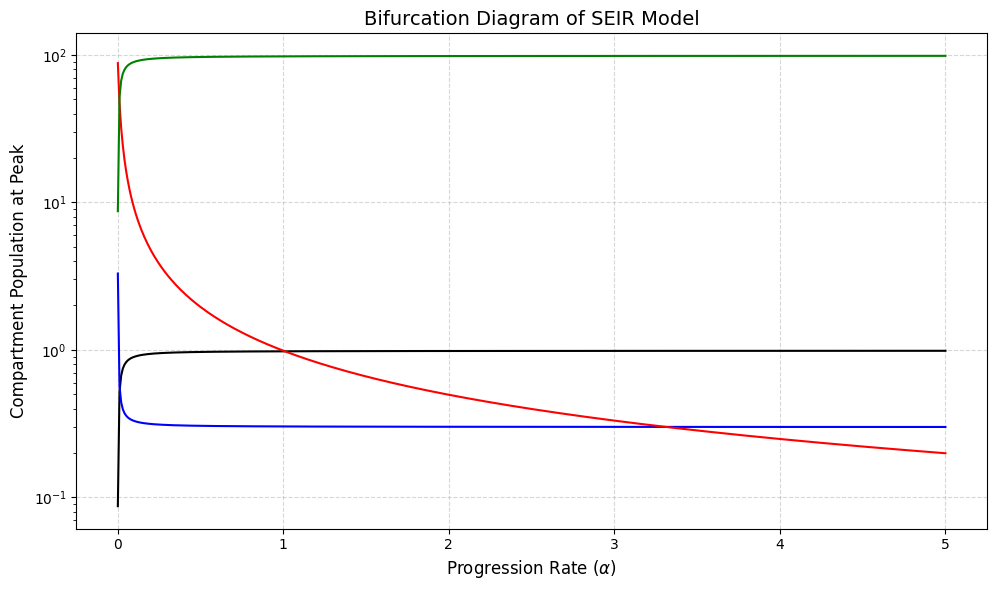

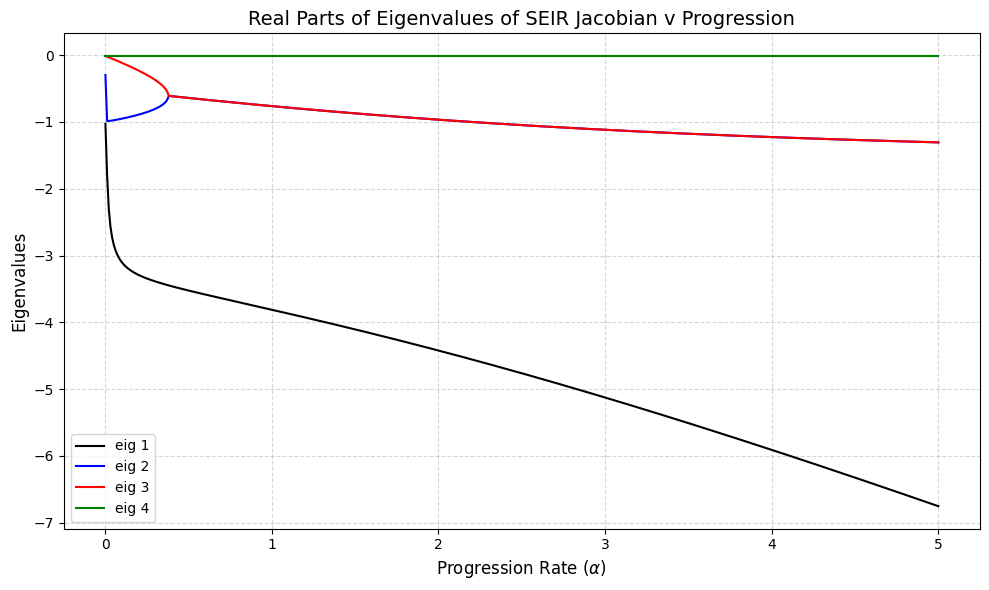

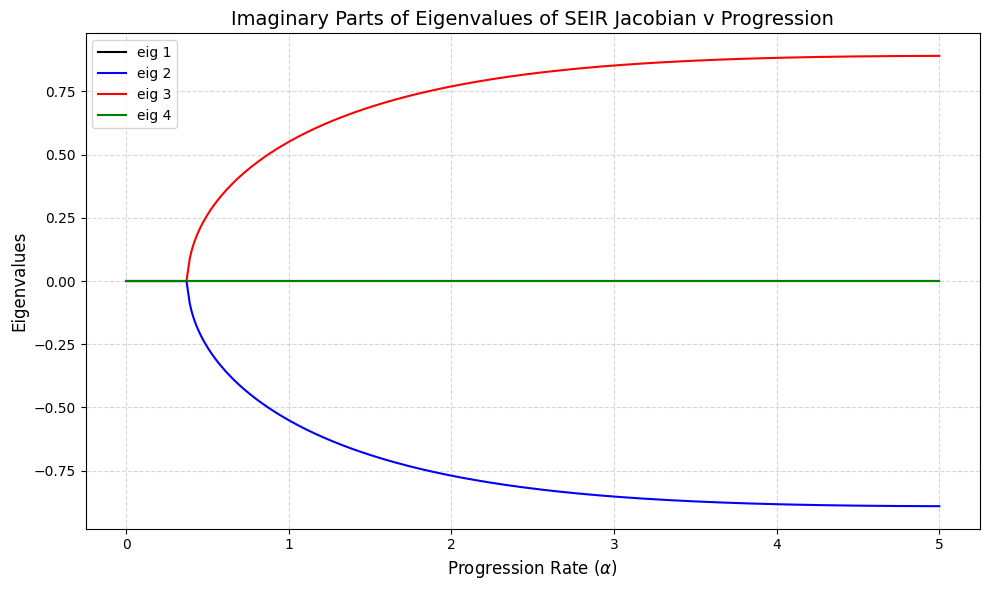

In [10]:
#bifurcation diagram for I* vs alpha
gamma = 1
#alpha = 0.29
#alpha = 2.347510026817774 #transition time from low to high density; not infectivity!
beta = 3.374 #calculated from root-finding the imaginary values in the Jacobian
mu = 0.01
Lambda = 1


#R0 = math.sqrt((alpha*beta*Lambda)/(mu*(mu+alpha)*(mu*gamma)))
#corrected from discussion with Brendan on R0 calculation 6/04
R0 = (Lambda/mu)*(beta/gamma) #here we assume a steady population where deaths and immigration over a three-week interval are negligible
#R0 = math.sqrt(Lambda/mu)*math.sqrt(beta/gamma) #here we assume a steady population where deaths and immigration over a three-week interval are negligible
print(R0)

alpha_min = 0.001
alpha_max = 5

alpha_evaluate = np.linspace(alpha_min, alpha_max, 500)
transient_time = 14 #model peaks quickly

bifurcation_alpha = []
bifurcation_I = []
bifurcation_S = []
bifurcation_E = []
bifurcation_R = []

ev0 = []
ev1 = []
ev2 = []
ev3 = []




for val in range(len(alpha_evaluate)):
    alpha = alpha_evaluate[val]
    #print(val)
    #print(beta)
    #breakpoint()
    I_steady = ((Lambda*alpha)/((gamma+mu)*(alpha+mu)))-(mu/beta)
    S_steady = ((gamma+mu)*(alpha+mu))/(alpha*beta)
    E_steady = gamma/(alpha+mu) - (mu*(gamma+mu))/(alpha*beta)
    R_steady = (gamma*Lambda*alpha)/(mu*(gamma+mu)*(alpha+mu)) - gamma/beta
    bifurcation_I.append(I_steady)
    bifurcation_S.append(S_steady)
    bifurcation_E.append(E_steady)
    bifurcation_R.append(R_steady)

    bifurcation_alpha.append(alpha)

    Jac = np.array([[-(Lambda*alpha*beta)/((alpha+mu)*(gamma+mu))-mu, 0, -((gamma+mu)*(alpha+mu))/alpha, 0], 
    [(Lambda*alpha*beta)/((alpha+mu)*(gamma+mu)), -alpha-mu, ((gamma+mu)*(alpha+mu))/alpha, 0],
    [0, alpha, -gamma-mu, 0],
    [0, 0, gamma, -mu]])

    eigs = np.linalg.eigvals(Jac)
    eigs_sorted = np.sort_complex(eigs)
    #eigs = np.array(list(eigenall.values()), dtype='complex')
    ev0.append(eigs_sorted[0])
    ev1.append(eigs_sorted[1])
    ev2.append(eigs_sorted[2])
    ev3.append(eigs_sorted[3])

ev2_array = np.array(ev2)
ev1_array = np.array(ev1)
ev3_array = np.array(ev3)
ev0_array = np.array(ev0)


plt.figure(figsize=(10, 6))
plt.plot(bifurcation_alpha, bifurcation_I, color='black') #, alpha=0.5)
plt.plot(bifurcation_alpha, bifurcation_S, color='blue') #, alpha=0.5)
plt.plot(bifurcation_alpha, bifurcation_E, color='red') #, alpha=0.5)
plt.plot(bifurcation_alpha, bifurcation_R, color='green') #, alpha=0.5)

plt.title('Bifurcation Diagram of SEIR Model', fontsize=14)
plt.xlabel('Progression Rate ($\\alpha$)', fontsize=12)
plt.ylabel('Compartment Population at Peak', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.yscale('log') #to better see dynamics since R dominates
plt.show()


#eigenvalue plot vs alpha, plot each of four vals separately
ev0_array_real = ev0_array.real
ev0_array_imag = ev0_array.imag
ev1_array_real = ev1_array.real
ev1_array_imag = ev1_array.imag
ev2_array_real = ev2_array.real
ev2_array_imag = ev2_array.imag
ev3_array_real = ev3_array.real
ev3_array_imag = ev3_array.imag


plt.figure(figsize=(10, 6))
plt.plot(bifurcation_alpha, ev0_array_real, color='black', label = 'eig 1') #, alpha=0.5)
plt.plot(bifurcation_alpha, ev1_array_real, color='blue', label = 'eig 2') #, alpha=0.5)
plt.plot(bifurcation_alpha, ev2_array_real, color='red', label = 'eig 3') #, alpha=0.5)
#plt.plot(bifurcation_alpha, ev2_array.imag, color = 'blue')
plt.plot(bifurcation_alpha, ev3_array_real, color='green', label = 'eig 4') #, alpha=0.5)
plt.legend()
plt.title('Real Parts of Eigenvalues of SEIR Jacobian v Progression', fontsize=14)
plt.xlabel('Progression Rate ($\\alpha$)', fontsize=12)
plt.ylabel('Eigenvalues', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.yscale('log') #to better see dynamics since R dominates
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(bifurcation_alpha, ev0_array_imag, color='black', label = 'eig 1') #, alpha=0.5)
plt.plot(bifurcation_alpha, ev1_array_imag, color='blue', label = 'eig 2') #, alpha=0.5)
plt.plot(bifurcation_alpha, ev2_array_imag, color='red', label = 'eig 3') #, alpha=0.5)
#plt.plot(bifurcation_alpha, ev2_array.imag, color = 'blue')
plt.plot(bifurcation_alpha, ev3_array_imag, color='green', label = 'eig 4') #, alpha=0.5)
plt.legend()
plt.title('Imaginary Parts of Eigenvalues of SEIR Jacobian v Progression', fontsize=14)
plt.xlabel('Progression Rate ($\\alpha$)', fontsize=12)
plt.ylabel('Eigenvalues', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.yscale('log') #to better see dynamics since R dominates
plt.show()
    

In [11]:
#Make plots on loop for SEIR
output_dir = "./saved_plots"
os.makedirs(output_dir, exist_ok=True)

alpha_evaluate = np.linspace(0.25, 5, 20)

gamma = 1
#alpha = 0.29
#alpha = 2.347510026817774 #transition time from low to high density; not infectivity!
beta = 3.374 #calculated from root-finding the imaginary values in the Jacobian
mu = 0.00003333333 #1/lifespan of person
Lambda = 0.001

#from literature: r0 = 2.2 giving beta=0.22


def model(t, state):
    S,E,I,R = state
    dSdt = Lambda - beta*S*I - mu*S
    dEdt = beta*S*I - alpha*E - mu*E
    dIdt = alpha*E - gamma*I - mu*I
    dRdt = gamma*I - mu*R
    return [dSdt,dEdt,dIdt,dRdt]

t_span = (0, 100)
initial = (90, 5, 5, 0)

t_evaluate = np.linspace(0, 100, 100)

for val in alpha_evaluate:
    alpha = val

    sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)

   # plt.figure(num="fig")
    plt.plot(sol.t, sol.y[0], label='S', color='blue')
    plt.plot(sol.t, sol.y[1], label='E', color='red')
    plt.plot(sol.t, sol.y[2], label='I', color='green')
    plt.plot(sol.t, sol.y[3], label='R', color='orange')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.legend()
    plt.grid(True)

    formatted_value = f"{val:.2f}".replace('.', '_')
    filename = os.path.join(output_dir, f"plot_{formatted_value}.png")
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    
    plt.close() #fig) 

    